This is the beginning file for milestone 2 requirements. Over the past few weeks my raw work is contained in the
raw_work folder and consists of the following files: data_wrangling.ipynb, data_wrangling_part2.ipynb, data_modeling.ipynb,
data_modeling_part2.ipynb, and data_visualization_static.ipynb.

The goals for this milestone were to work on finalizing the data, build a model and create a static dashboard.

I would like to note that the 3 required files im creating for this milestone is going to be the best way I can possibly outlined what I have done but this process for me was very iterative. I had to go back and redo aspects of data wrangling based on how modeling changes and how my understanding of the project and what I want to do changed. I even changed my modeling after the modeling ipynb. Additionally, the scraping code I have in here took about 3 straight days to run so im going to add the code but then also add the csvs so you dont actually have to run the scraping code.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from newspaper import Article
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display, clear_output
data = pd.read_csv("cleaned_data.csv")

In [2]:
data.tail()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
107800,1411291,UPDATE: Van Natta To Stay On As Board of Direc...,https://www.benzinga.com/news/11/11/2138052/up...,Allie Wickman,2011-11-17 00:00:00,ZNGA,Movement
107801,1411292,Zynga Executive Van Natta Resigns -WSJ,https://www.benzinga.com/news/11/11/2138049/zy...,Allie Wickman,2011-11-17 00:00:00,ZNGA,General
107802,1411293,Hearing Zynga Asks Some Workers to Surrender P...,https://www.benzinga.com/news/11/11/2115786/he...,Allie Wickman,2011-11-10 00:00:00,ZNGA,Movement
107803,1411294,Is Zynga's Pre-Thanksgiving IPO a Turkey?,https://www.benzinga.com/markets/11/11/2099363...,Zentrader,2011-11-06 00:00:00,ZNGA,General
107804,1411295,Zynga Files New S-1 Stament for IPO; Cash on H...,https://www.benzinga.com/news/11/11/2097650/zy...,Eddie Staley,2011-11-04 00:00:00,ZNGA,General


The goal for this file is to create a pipeline for data cleaning and save a csv file after cleaning. We discussed in class the primary cleaning categories being Data type fixes, Missing values, Standardization, and Obvious errors. After our group conversation with Sibi we discussed a two week plan to handle my data due to its nature. First, I will be focusing on removing the general and movement articles, formatting the published_at column date so that it can be read by yFinance which is what is going to be used to determine the changes in stock price after article publication dates, I will investigate how the number of valid publishers changes as I impose limits on the minimum number of articles written because each publisher needs to write enough articles to have enough data to be classified, and lastly I will add the  stock price after publication to the columns. As discussed in previous work, there are no missing values or obvious errors. 

In [3]:
len(data)

107805

In [4]:
data['Headline_Class'].value_counts()

Headline_Class
General       48544
Movement      28957
Analysis      25965
Prediction     4339
Name: count, dtype: int64

Take only the analysis and prediction columns. Later on in the notebook I will improve the analysis and prediction column using the article text rather than headline text but first scraping needs to be done.

In [5]:
new_data = data[data['Headline_Class'].isin(['Analysis', 'Prediction'])].copy()

In [6]:
len(new_data)

30304

Investigating the publishers left and the amount of articles they wrote

In [7]:
new_data["publisher"].value_counts() #360 publishers left after removing 70% of the data due to general or movement articles 

publisher
Paul Quintaro                  4244
Charles Gross                  2889
Benzinga Newsdesk              2428
Lisa Levin                     2321
Vick Meyer                     1968
                               ... 
Abhi Rao                          1
Steve Evans - MoneyGeek.com       1
KomfieM                           1
Dave Moenning                     1
Ian Kar                           1
Name: count, Length: 360, dtype: int64

In [8]:
new_data["publisher"].value_counts().describe()

count     360.000000
mean       84.177778
std       364.280833
min         1.000000
25%         1.000000
50%         5.000000
75%        22.250000
max      4244.000000
Name: count, dtype: float64

Text(0.5, 1.0, 'Articles published per publisher')

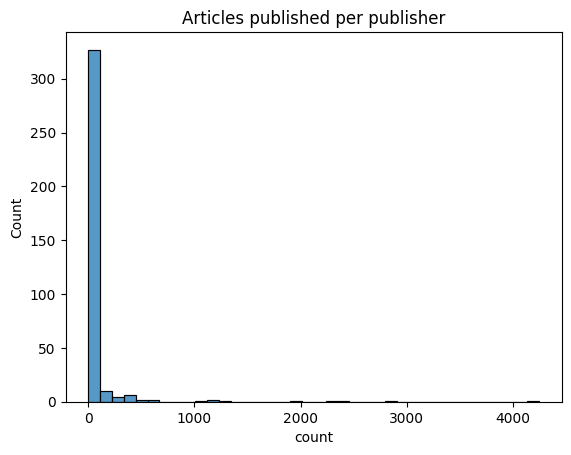

In [9]:
sns.histplot(new_data["publisher"].value_counts())
plt.title('Articles published per publisher')

Understanding how publisher count changes with different article thresholds:

In [10]:
publisher_thresholds = [5, 10, 25, 50, 100, 1000]
for amount in publisher_thresholds:
    print(f"Threshold {amount}: {(new_data['publisher'].value_counts() >= amount).sum()} publishers left")

Threshold 5: 186 publishers left
Threshold 10: 140 publishers left
Threshold 25: 86 publishers left
Threshold 50: 59 publishers left
Threshold 100: 37 publishers left
Threshold 1000: 9 publishers left


For the purposes of this project I am going to only use publishers that have made a minimum of 25 publications. Anything less is not enough to establish a track record. However for the purposes of the dashboard I still may include the publishers with less than 25 articles as a means to alert retail investors that these publishers have not contributed enough for me to say if they are trustworthy or not.

In [11]:
publisher_amount = new_data['publisher'].value_counts()
publisher_cutoff = publisher_amount[publisher_amount >= 25].index
data_filtered_publisher = new_data[new_data['publisher'].isin(publisher_cutoff)].copy()

In [12]:
len(data_filtered_publisher)

28863

In [13]:
data_filtered_publisher["publisher"].value_counts().describe()

count      86.000000
mean      335.616279
std       690.161416
min        25.000000
25%        42.500000
50%        75.000000
75%       266.750000
max      4244.000000
Name: count, dtype: float64

For now every publisher has at least published 25 articles leaving us with 86 total publishers with a mean published amount of 335 and standard deviation of 690 articles. Next I will format the published_at column properly. Thankfully we have had months of practice in ml class using pd.to_datetime.

In [14]:
data_filtered_publisher['published_at'].dtype

dtype('O')

In [15]:
data_filtered_publisher['published_at'] = pd.to_datetime(data_filtered_publisher['published_at'], format='mixed', utc=True)

In [16]:
data_filtered_publisher.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 14:57:41+00:00,ADBE,Analysis
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 14:19:31+00:00,ADBE,Analysis
5,21996,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14 13:31:09+00:00,ADBE,Analysis
6,21997,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14 10:19:39+00:00,ADBE,Analysis
9,22000,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30 14:03:54+00:00,ADBE,Analysis


In [17]:
data_filtered_publisher['published_at'].dtype

datetime64[ns, UTC]

In [18]:
data_filtered_publisher['published_at'] = data_filtered_publisher['published_at'].dt.date

Check for missing values:

In [19]:
data_filtered_publisher['published_at'].isna().sum()

np.int64(0)

In [21]:
#data_filtered_publisher.to_csv('wrangled_data.csv', index=False)
data = pd.read_csv('wrangled_data.csv')

The goal for the second week of wrangling is to focus on encoding, derived features, date/time encoding, and numeric transformations. However, due to the nature of this project I will stray to some extent from the core goal. This is the week where I need to go through all the remaining articles in the data set and come up with a way to figure out if they are talking about short term or long term analysis and predictions and engineer/encode a new column that indicates this. Additionally, I need to finish the date/time encoding so yFinance can read the date and time and figure how how to handle days where the market is closed or how to standardized the time intervals and create the columns that have the tickers performances x amount of days after the article publication date.

In [22]:
data.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08,ADBE,Analysis
1,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20,ADBE,Analysis
2,21996,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14,ADBE,Analysis
3,21997,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14,ADBE,Analysis
4,22000,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30,ADBE,Analysis


All of my scraping work can be found in data_wrangling_part2.ipynb but for the purposes of this milestone ill just include what I ended up using.

For feature engineering, I am going to drop article_id because it is not useful, Headline_Class will be one hot encoded, I will create the column we talked about for the low, medium, high encoded article counts, and the 3 yFinance return columns.

In [23]:
data = data.drop('article_id', axis=1)

In [24]:
data = pd.get_dummies(data, columns=['Headline_Class'], drop_first=True, dtype=int)
data.head()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction
0,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08,ADBE,0
1,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20,ADBE,0
2,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14,ADBE,0
3,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14,ADBE,0
4,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30,ADBE,0


In [25]:
publisher_count = data['publisher'].value_counts()
publisher_count

publisher
Paul Quintaro        4244
Charles Gross        2889
Benzinga Newsdesk    2428
Lisa Levin           2321
Vick Meyer           1968
                     ... 
Alex Furno             29
John Harris            29
Spencer Israel         27
Luke J Jacobi          25
Hilary Farrell         25
Name: count, Length: 86, dtype: int64

Get total article count for each publisher and add it as a column

In [26]:
data['total_article_count'] = data['publisher'].map(publisher_count)
data.tail()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count
28858,"Wedbush Initiates Zynga at Outperform, $12.50 PT",https://www.benzinga.com/analyst-ratings/price...,Juan Lopez,2011-12-20,ZNGA,0,1314
28859,"Wedbush Initiates Zynga Coverage: Outperform, ...",https://www.benzinga.com/analyst-ratings/analy...,Hilary Farrell,2011-12-19,ZNGA,0,25
28860,BTIG Initiates Coverage of Zynga with Buy Rati...,https://www.benzinga.com/analyst-ratings/initi...,Matthew Kennedy,2011-12-16,ZNGA,0,76
28861,"UPDATE: Sterne Agee Initiates Underperform, PT...",https://www.benzinga.com/analyst-ratings/analy...,David Johnson,2011-12-13,ZNGA,0,378
28862,"Sterne Agee Initiates Zynga at Underperform, $...",https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-12-13,ZNGA,0,401


In [27]:
data['total_article_count'].describe()

count    28863.000000
mean      1738.361536
std       1390.769282
min         25.000000
25%        413.000000
50%       1314.000000
75%       2428.000000
max       4244.000000
Name: total_article_count, dtype: float64

In [28]:
def encode_article_counts(publisher): # Encoding based off of the describe() data
    if publisher <= 413:
        return 0
    elif publisher <= 2428:
        return 1
    else:
        return 2
data['publisher_size'] = data['total_article_count'].apply(encode_article_counts)
data.tail()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size
28858,"Wedbush Initiates Zynga at Outperform, $12.50 PT",https://www.benzinga.com/analyst-ratings/price...,Juan Lopez,2011-12-20,ZNGA,0,1314,1
28859,"Wedbush Initiates Zynga Coverage: Outperform, ...",https://www.benzinga.com/analyst-ratings/analy...,Hilary Farrell,2011-12-19,ZNGA,0,25,0
28860,BTIG Initiates Coverage of Zynga with Buy Rati...,https://www.benzinga.com/analyst-ratings/initi...,Matthew Kennedy,2011-12-16,ZNGA,0,76,0
28861,"UPDATE: Sterne Agee Initiates Underperform, PT...",https://www.benzinga.com/analyst-ratings/analy...,David Johnson,2011-12-13,ZNGA,0,378,0
28862,"Sterne Agee Initiates Zynga at Underperform, $...",https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-12-13,ZNGA,0,401,0


Now the hard part is actually adding the yFinance columns. I need a formula to ensure consistency across all the data. For the starting date by default it is the published date but if that is not on a trading day then the next possible trading day becomes the starting point. Same idea for the end of the interval, the first valid trading day on or after the 7 day, 30 day, 6 month period.

In [30]:
data.dtypes

headline                     object
url                          object
publisher                    object
published_at                 object
ticker                       object
Headline_Class_Prediction     int64
total_article_count           int64
publisher_size                int64
dtype: object

In [31]:
data['published_at'].head()

0    2020-06-08
1    2020-05-20
2    2020-05-14
3    2020-05-14
4    2020-04-30
Name: published_at, dtype: object

In [32]:
data['published_at'] = pd.to_datetime(data['published_at'], errors='raise').dt.normalize()
data.dtypes

headline                             object
url                                  object
publisher                            object
published_at                 datetime64[ns]
ticker                               object
Headline_Class_Prediction             int64
total_article_count                   int64
publisher_size                        int64
dtype: object

In [33]:
import yfinance as yf
columns = {
    "return_7d": 7,
    "return_30d": 30,
    "return_6m": 182
}
download_date = (data['published_at'].min() - pd.Timedelta(days=7)).date()
download_end = (data['published_at'].max() + pd.Timedelta(days=182)).date()
current_tickers = data['ticker'].unique()

In [34]:
current_tickers

array(['ADBE', 'AIG', 'AMD', 'ATVI', 'AVGO', 'AXP', 'AZN', 'BABA', 'BAC',
       'BIIB', 'BMY', 'CAT', 'CMCSA', 'CMG', 'COP', 'DB', 'DE', 'DG',
       'EA', 'EBAY', 'FDX', 'GILD', 'GME', 'HAL', 'HD', 'INTC', 'JNJ',
       'KSS', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'MDT', 'MRK', 'MS', 'MU',
       'MYL', 'NFLX', 'NOK', 'NVDA', 'ORCL', 'PFE', 'QCOM', 'TSLA', 'TXN',
       'WFC', 'YELP', 'YUM', 'ZNGA'], dtype=object)

In [35]:
prices = {}
delisted_tickers = []
for ticker in current_tickers:
    ydata = yf.download(ticker, start=download_date, end=download_end, progress=False)
    if ydata is None or ydata.empty:
        delisted_tickers.append(ticker)
    # if the tickers delisted keep track so I can remove them later
    # otherwise convert to proper date format, fix the double array and check both adj close and close because data is different
    ydata.index = pd.to_datetime(ydata.index).normalize()
    if isinstance(ydata.columns, pd.MultiIndex):
        ydata = ydata.xs(ticker, axis=1, level=1, drop_level=True) # I looked up how to do this step yfinance does not have consistent formatting for some reason
    if 'Adj Close' in ydata.columns:
        prices[ticker] = ydata['Adj Close'].dropna()
    elif 'Close' in ydata.columns:
        prices[ticker] = ydata['Close'].dropna()
    else:
        delisted_tickers.append(ticker)
#print(ydata.columns)
#print(ydata.head())
print("Tickers:", len(prices))
print("Delisted:", len(delisted_tickers))
print(delisted_tickers)

$ATVI: possibly delisted; no timezone found

1 Failed download:
['ATVI']: possibly delisted; no timezone found
$MYL: possibly delisted; no timezone found

1 Failed download:
['MYL']: possibly delisted; no timezone found
$ZNGA: possibly delisted; no timezone found

1 Failed download:
['ZNGA']: possibly delisted; no timezone found


Tickers: 50
Delisted: 3
['ATVI', 'MYL', 'ZNGA']


1460 rows that use delisted tickers. Since its a small amount of data im just going to remove them, remove any publishers that dropped below my 25 threshold and redo the encoding because the mean and std are going to change. 

In [36]:
row_removal = data[data['ticker'].isin(delisted_tickers)].index
data = data.drop(row_removal).copy()
len(data)

27403

In [37]:
publisher_count = data['publisher'].value_counts()
publisher_count.describe()

count      86.000000
mean      318.639535
std       652.997089
min        23.000000
25%        39.250000
50%        72.000000
75%       261.750000
max      4043.000000
Name: count, dtype: float64

In [38]:
publisher_amount = data['publisher'].value_counts()
publisher_cutoff = publisher_amount[publisher_amount >= 25].index
data_filtered_publisher = data[data['publisher'].isin(publisher_cutoff)].copy()
len(data_filtered_publisher)

27357

In [39]:
data_filtered_publisher['total_article_count'].describe()

count    27357.000000
mean      1736.017582
std       1390.166651
min         25.000000
25%        413.000000
50%       1314.000000
75%       2428.000000
max       4244.000000
Name: total_article_count, dtype: float64

Only 50 rows were removed so 25, 50, 75% cutoffs did not change so no need to redo encoding.
Now I need to make the 3 yfinance columns, transfer the data and check everything worked

In [40]:
data = data_filtered_publisher.copy()

In [41]:
data['return_7d'] = np.nan
data['return_30d'] = np.nan
data['return_6m'] = np.nan
data.tail()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size,return_7d,return_30d,return_6m
28458,UPDATE: J.P. Morgan Raises Price Target on Yum...,https://www.benzinga.com/analyst-ratings/analy...,Steven Anfield,2011-12-08,YUM,0,30,0,NaN,NaN,NaN
28459,JP Morgan Raises PT on Yum Brands to $68,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-12-08,YUM,0,401,0,NaN,NaN,NaN
28460,YUM! Cites Dividends and Buybacks as Ways to R...,https://www.benzinga.com/news/11/12/2183552/yu...,Matthew Kennedy,2011-12-07,YUM,0,76,0,NaN,NaN,NaN
28461,"Jefferies Reiterates Hold, $55 Target on Yum! ...",https://www.benzinga.com/analyst-ratings/analy...,Phil Marsh,2011-12-06,YUM,0,99,0,NaN,NaN,NaN
28462,Yum! Brands Announces Full-Year 2012 Expectati...,https://www.benzinga.com/news/11/12/2174970/yu...,Matthew Kennedy,2011-12-05,YUM,1,76,0,NaN,NaN,NaN


In [42]:
for i in range(len(data)):
    # go through each row
    ticker = data.iloc[i]['ticker'] # get the ticker at the row
    date = data.iloc[i]['published_at'] # get the date article was published for the ticker at the row

    price_history = prices[ticker] # get the entire price history for the current ticker of the current row
    trading_days = price_history.index[price_history.index >= date] #get all valid trading days on or after published at date ie no holiday no weekend

    first_valid_day = trading_days[0] # first trading day on or after publication date
    first_stock_price = float(price_history.loc[first_valid_day]) # get stock price on first trading day on or after publicationd ate

    # now handle 7 day, 30, 6m returns 7day first

    seven_day = first_valid_day + pd.Timedelta(days=7) # get 7 days after published date then need to check if trading day
    valid_seven_days = price_history.index[price_history.index >= seven_day] #first valid trading days oon or after the 7th day

    if (len(valid_seven_days) > 0):
        valid_seven_day = valid_seven_days[0]
        seven_day_price = float(price_history.loc[valid_seven_day]) # stock price in the 7 day

        data.iloc[i, data.columns.get_loc('return_7d')] = (seven_day_price - first_stock_price) / first_stock_price # store the % return in 7 days

    # same thing for 30 day and 6 month

    thirty_day = first_valid_day+ pd.Timedelta(days=30) # get 30 days after published date then need to check if trading day
    valid_thirty_days = price_history.index[price_history.index >= thirty_day] #first valid trading days oon or after the 30th day

    if (len(valid_thirty_days) > 0):
        valid_thirty_day = valid_thirty_days[0]
        thirty_day_price = float(price_history.loc[valid_thirty_day]) # stock price in the 30 day

        data.iloc[i, data.columns.get_loc('return_30d')] = (thirty_day_price - first_stock_price) / first_stock_price # store the % return in 30 days


    six_month = first_valid_day + pd.Timedelta(days=182) # get 182 days after published date then need to check if trading day
    valid_six_months = price_history.index[price_history.index >= six_month] #first valid trading days oon or after the 182nd day

    if (len(valid_six_months) > 0):
        valid_six_month = valid_six_months[0]
        six_month_price = float(price_history.loc[valid_six_month]) # stock price in the 6th month

        data.iloc[i, data.columns.get_loc('return_6m')] = (six_month_price - first_stock_price) / first_stock_price # store the % return in 182 days



In [43]:
data[['return_7d', 'return_30d', 'return_6m']].describe()

,return_7d,return_30d,return_6m
count,27357.000000,27357.000000,27343.000000
mean,0.003196,0.015666,0.127252
std,0.053642,0.106197,0.335118
min,-0.457053,-0.673156,-0.730762
25%,-0.019812,-0.035492,-0.040199
50%,0.003393,0.015902,0.082839
75%,0.025773,0.063101,0.220809
max,0.492858,1.087066,5.114833


In [44]:
data[['return_7d', 'return_30d', 'return_6m']].isna().mean()

return_7d     0.000000
return_30d    0.000000
return_6m     0.000512
dtype: float64

In [45]:
#data.to_csv('data_wrangling_part2.csv', index=False)
data = pd.read_csv('data_wrangling_part2.csv')

After multiple attempts from scraping, my process was either too slow, would time out, or I would get blocked while scraping. As a result I used AI to improved my code by adding concurrent features and multithreading. 

I am going to put the final code I used here. However, this is not necessarily perfectly reproducible because I ran this for three days straight and performance depends on internet. 

**I woult NOT suggest running this but you can if you want** if you do I would also suggest using hipergator

Just in case I will have a csv with the scraping results from what I did loaded after just for continuity. 

In [47]:
data.to_csv('temp_scrape_resume.csv', index=False)

In [ ]:
import requests
import trafilatura
from concurrent.futures import ThreadPoolExecutor, as_completed

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    )
}

def get_article_text(url):
    if pd.isna(url) or not str(url).strip(): # check if the text is empty
        return ""

    try:
        response = requests.get(str(url).strip(), headers=headers, timeout=15) # try for 15 seconds to get the text at url
        response.raise_for_status()

        text = trafilatura.extract(
            response.text,
            favor_precision=True,
            include_comments=False,
            include_tables=False
        )

        return text.strip() if text else ""

    except Exception:
        return ""


data = pd.read_csv("temp_scrape_resume.csv")
if "article_text" not in data.columns: # if we havent already scraped make the remaining columns empty
    data["article_text"] = ""

mask_missing = data["article_text"].fillna("").astype(str).str.strip().eq("") # ensure they are empty because I had issues with partial scrape
missing_idx = data.index[mask_missing].tolist()

print("Rows still missing:", len(missing_idx))
print("Rows already scraped:", (~mask_missing).sum())

with ThreadPoolExecutor(max_workers=4) as executor: # with 4 workers at a time try to scrape the indices that are missing text
    futures = {
        executor.submit(get_article_text, data.at[idx, "url"]): idx
        for idx in missing_idx
    }

    completed = 0
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx = futures[future]
        text = future.result()

        if isinstance(text, str) and text.strip() != "":
            data.at[idx, "article_text"] = text

        completed += 1

        if completed % 500 == 0: # every time 500 have been scraped save progress just in case my internet goes out
            data.to_csv("temp_scrape_resume.csv", index=False)

data.to_csv("temp_scrape_resume.csv", index=False)

**I am assuming you didnt do any scraping but you can change this line if you did**

**I am loading the csv file with the scraping I was able to do for the rest of this project**

In [48]:
data = pd.read_csv('final_scrape.csv')
data.head()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size,return_7d,return_30d,return_6m,article_text
0,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08,ADBE,0,2428,1,0.008950,0.150586,0.237493,Never miss a trade again with the fastest news...
1,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20,ADBE,0,94,0,-0.022052,0.115684,0.197690,Never miss a trade again with the fastest news...
2,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14,ADBE,0,2321,1,0.075354,0.129295,0.301612,Upgrades\r\nDowngrades\r\nInitiations\r\n© 202...
3,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14,ADBE,0,1968,1,0.075354,0.129295,0.301612,Never miss a trade again with the fastest news...
4,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30,ADBE,0,1968,1,0.037156,0.101911,0.303897,Never miss a trade again with the fastest news...


In [49]:
# Check performance
scraped_articles = data['article_text'].fillna("").astype(str).str.strip().ne("").sum()
print(scraped_articles)

23908


After 3 straight days of scraping in increments to avoid ip bans 23908 was the amount of articles I could obtain. Theoretically there are probably more I could scrape but for the sake of this milestone I am going to work with this data

In [50]:
# Remove Rows without text
data["article_text"] = data["article_text"].fillna("").astype(str)

non_empty = data["article_text"].str.strip().ne("").sum()
empty = data["article_text"].str.strip().eq("").sum()

print("Total rows:", len(data))
print("Rows with article text:", non_empty)
print("Rows without text:", empty)

Total rows: 27357
Rows with article text: 23908
Rows without text: 3449


In [51]:
#Remove the rows I couldnt scrape
data = data[data["article_text"].str.strip().ne("")].copy()
len(data)

23908

In [52]:
data["publisher"].value_counts().describe() # Check publisher counts

count      80.000000
mean      298.850000
std       599.599679
min         3.000000
25%        35.000000
50%        69.000000
75%       235.000000
max      3615.000000
Name: count, dtype: float64

In [53]:
publisher_amount = data['publisher'].value_counts()
publisher_cutoff = publisher_amount[publisher_amount >= 25].index
data = data[data['publisher'].isin(publisher_cutoff)].copy()
len(data)

23837

In [54]:
data['total_article_count'].describe()  # Rencode based on new values

count    23837.000000
mean      1768.651676
std       1387.097502
min         29.000000
25%        429.000000
50%       1314.000000
75%       2428.000000
max       4244.000000
Name: total_article_count, dtype: float64

In [55]:
def encode_article_counts(publisher):
    if publisher <= 429:
        return 0
    elif publisher <= 2428:
        return 1
    else:
        return 2
data['publisher_size'] = data['total_article_count'].apply(encode_article_counts)
data.tail()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size,return_7d,return_30d,return_6m,article_text
27351,"Bank of America Maintains Buy, $67 Target on Y...",https://www.benzinga.com/analyst-ratings/analy...,Phil Marsh,2011-12-08,YUM,0,99,0,0.000174,0.037050,0.171840,Bank of America reiterates its Buy rating and ...
27353,JP Morgan Raises PT on Yum Brands to $68,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-12-08,YUM,0,401,0,0.000174,0.037050,0.171840,© 2026 Benzinga.com. Benzinga does not provide...
27354,YUM! Cites Dividends and Buybacks as Ways to R...,https://www.benzinga.com/news/11/12/2183552/yu...,Matthew Kennedy,2011-12-07,YUM,0,76,0,-0.011033,0.031718,0.160814,Never miss a trade again with the fastest news...
27355,"Jefferies Reiterates Hold, $55 Target on Yum! ...",https://www.benzinga.com/analyst-ratings/analy...,Phil Marsh,2011-12-06,YUM,0,99,0,0.016571,0.036455,0.133400,Jefferies maintains its Hold rating and $55 ta...
27356,Yum! Brands Announces Full-Year 2012 Expectati...,https://www.benzinga.com/news/11/12/2174970/yu...,Matthew Kennedy,2011-12-05,YUM,1,76,0,0.032756,0.032930,0.135161,"Yum! Brands Inc. (NYSE:\r\nYUM), in advance of..."


I interrupted the code below it will take about an hour-2 to run properly

In [56]:
from transformers import pipeline
# finbert analysis 
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert"
)

texts = data["article_text"].fillna("").astype(str).tolist()

prediction_list = []
batch_size = 16

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    preds = finbert(batch, truncation=True)
    prediction_list.extend(preds)

data["finbert_label"] = [prediction["label"] for prediction in prediction_list]
data["finbert_score"] = [prediction["score"] for prediction in prediction_list]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\andre\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

 55%|█████▍    | 813/1490 [32:03<26:41,  2.37s/it]


KeyboardInterrupt: 

Encode the finbert sentiment scores:

In [ ]:
encode_sentiment = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

data["sentiment_encoded"] = data["finbert_label"].map(encode_sentiment)
#data.to_csv('sentiment_analysis.csv', index = False)

In [57]:
data = pd.read_csv('sentiment_analysis.csv')

In [58]:
print(data["finbert_label"].value_counts())
print(data[["finbert_label", "finbert_score"]].tail())

finbert_label
neutral     19115
negative     2901
positive     1892
Name: count, dtype: int64
      finbert_label  finbert_score
23903       neutral       0.795712
23904       neutral       0.939211
23905       neutral       0.932860
23906      positive       0.717313
23907      positive       0.948789


add a long term / short term column based on the text scraped from the articles. Second, I need to update the prediction / analysis column using the article text rather than the headline text. Lastly, I need to classify the author as accurate or not accurate if its sentiment is in the same direction as the corresponding time range. 

In [59]:
short_term = [
    "short term","near term","near-term","this week","next week",
    "this month","next month","coming days","coming weeks",
    "immediate","soon","trading","momentum","technical analysis", "day",
    "week", "near", "recent"
]

long_term = [
    "long term","long-term","over time","long run","multi year","multi-year",
    "next year","coming year","coming years","buy and hold",
    "long term growth","investment horizon","long term investors", "hold", "year", "earnings",
    "growth", "fundamentals", "dividend", "retirement", "valuation"
]

In [60]:
# return 1 if its long term and 0 if its short
def classify_time(text):
    
    text = text.lower()

    short_score = sum(term in text for term in short_term)
    long_score = sum(term in text for term in long_term)

    if long_score > short_score:
        return 1   
    else:
        return 0  

In [61]:
data["long_term"] = data["article_text"].apply(classify_time)

In [62]:
data["long_term"].value_counts()

long_term
0    21535
1     2373
Name: count, dtype: int64

Update the analysis / prediction column using article text and check the counts for each. I want to use headline to supplement the article text because I think headlines do a good job grasping the nature of the article.

In [63]:
Analysis = [
    "analysis", "analyst", "analysts",
    "upgrade", "upgraded", "upgrades",
    "downgrade", "downgraded", "downgrades",
    "initiates", "initiated", "initiate coverage", "coverage initiated",
    "reiterates", "reaffirmed", "maintains", "maintained",
    "rating", "ratings", "rated",
    "price target", "target price", "raises target", "cuts target",
    "buy rating", "sell rating", "hold rating",
    "outperform", "overweight", "equal weight", "underweight",
    "market perform", "sector perform", "neutral",
    "bullish", "bearish",
    "valuation", "valued", "multiple", "multiples",
    "fundamentals", "fundamental",
    "thesis", "case for", "case against",
    "recommendation", "recommend", "recommends",
    "estimate revision", "revised estimate", "eps estimate",
    "brokerage", "research note", "coverage",
    "buy", "sell", "hold"
]

Prediction = [
    "predict", "predicts", "predicted", "prediction", "predictions",
    "expects", "expected", "expecting",
    "forecast", "forecasts", "forecasted",
    "outlook", "guidance",
    "projects", "projected", "project",
    "could", "may", "might", "likely", "unlikely",
    "should", "would", "can", "possible", "possibly",
    "potential", "upside", "downside",
    "next quarter", "next year", "in 2026", "by 2027",
    "set to", "poised to", "on track to",
    "will rise", "will fall", "will climb", "will drop",
    "surge", "plunge", "rally", "decline",
    "headwind", "tailwind",
    "scenario", "base case", "bull case", "bear case"
]

In [64]:
def classify_article_type(headline, article_text):

    text = str(headline).lower() + " " + str(article_text).lower()

    analysis_score = sum(text.count(word) for word in Analysis)
    prediction_score = sum(text.count(word) for word in Prediction)

    if analysis_score > prediction_score:
        return 0   
    else:
        return 1  

data["Headline_Class_Prediction"] = data.apply(
    lambda row: classify_article_type(row["headline"], row["article_text"]),
    axis=1
)

In [65]:
data['Headline_Class_Prediction'].value_counts()

Headline_Class_Prediction
0    16112
1     7796
Name: count, dtype: int64

Calculate accuracy using voltatility and longterm/shorterm. If its neutral make sure price is within volatility range if its positive or negative just make sure the direction is the same.

In [66]:
data = pd.read_csv('modeling.csv')

In [67]:
volatility_7d = data.groupby("ticker")["return_7d"].std()
volatility_30d = data.groupby("ticker")["return_30d"].std()
volatility_6m = data.groupby("ticker")["return_6m"].std()

In [68]:
data["vol_7d"] = data["ticker"].map(volatility_7d)
data["vol_30d"] = data["ticker"].map(volatility_30d)
data["vol_6m"] = data["ticker"].map(volatility_6m)

In [69]:
def set_accuracy(row):
    sentiment = row["sentiment_encoded"]
    
    if row["long_term"] == 1:
        r = row["return_6m"]
        vol = row["vol_6m"]
        
        if pd.isna(r) or pd.isna(vol):
            return np.nan
        
        if sentiment == 1:   
            return 1 if r > 0 else 0
        elif sentiment == -1:   
            return 1 if r < 0 else 0
        elif sentiment == 0:  
            return 1 if abs(r) < vol else 0

    else:
        r30 = row["return_30d"]
        r7 = row["return_7d"]
        vol30 = row["vol_30d"]
        vol7 = row["vol_7d"]
        
        if pd.isna(r30) or pd.isna(r7) or pd.isna(vol30) or pd.isna(vol7):
            return np.nan
        
        if abs(r30) < vol30:
            r = r7
            vol = vol7
        else:
            r = r30
            vol = vol30
        
        if sentiment == 1:   
            return 1 if r > 0 else 0
        elif sentiment == -1:   
            return 1 if r < 0 else 0
        elif sentiment == 0:   
            return 1 if abs(r) < vol else 0
    
    return np.nan

data["accuracy"] = data.apply(set_accuracy, axis=1)

In [70]:
data["accuracy"].value_counts()

accuracy
1.0    13910
0.0     9997
Name: count, dtype: int64

The method shown above that we discussed in class performed much better than what I was doing in data_modeling_part2.ipynb.